In [1]:
from IPython.display import HTML, Javascript, display

display(HTML("""
<style>
a[href^="http://"],
a[href^="https://"] {
    color: blue !important;
}

/* stil za sve tabele */
table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important;
    max-width: none !important;
    table-layout: auto !important;
    border-collapse: collapse !important;
    font-family: "Segoe UI", "Calibri", sans-serif !important;
    font-size: 12px !important;
}

th, td {
    padding: 8px 20px !important;
}

/* markdown tabela – zadrži staro ponašanje */
table:not(.dataframe) tr:first-child th {
    border-bottom: 2px solid #222 !important;
}

/* dataframe – samo pravo zaglavlje */
table.dataframe thead tr:first-child th {
    border-bottom: 2px solid #222 !important;
}

/* index kolona dataframe da ne bude bold */
table.dataframe tbody th {
    font-weight: normal !important;
}

/* linija ispod poslednjeg reda */
tbody tr:last-child td,
tbody tr:last-child th {
    border-bottom: 1px solid #aaa !important;
}

/* caption */
caption,
.table-caption,
p.caption,
div.caption,
figcaption {
    text-align: center !important;
    font-weight: bold !important;
}
</style>
"""))

display(Javascript("""
function promeniTableUTabela() {
    const selectors = [
        "caption",
        ".table-caption",
        "p.caption",
        "div.caption",
        "figcaption",
        ".caption-number"
    ];

    document.querySelectorAll(selectors.join(",")).forEach(function(el) {
        if (el.innerHTML.includes("Table")) {
            el.innerHTML = el.innerHTML.replace(/\\bTable\\b/g, "Tabela");
        }
    });
}

promeniTableUTabela();

/* ako se notebook kasnije rerenderuje */
const observer = new MutationObserver(function() {
    promeniTableUTabela();
});

observer.observe(document.body, {
    childList: true,
    subtree: true
});
"""))

<IPython.core.display.Javascript object>

#  Ansambl metode

Ansambl metode zasnivaju se na ideji da se, umesto jednog modela, koristi više pojedinačnih modela koji su objedinjeni u jedinstven ansambl. Kombinovanjem većeg broja pouzdanih modela smanjuje se uticaj grešaka i postižu se veća tačnost i stabilnost, jer se njihovim zajedničkim delovanjem poništavaju nezavisne ili slabo povezane greške.

**Ishodi učenja:** Nakon savladavanja ovog poglavlja, student će biti u stanju da:

- objasni osnovnu ideju ansambl metoda i razliku u odnosu na pojedinačne modele  
- razlikuje ključne pristupe kao što su bagging, boosting i random forest  
- primeni ansambl metode u tipičnim ekonomskim problemima klasifikacije i regresije  
- interpretira rezultate modela i proceni njihov doprinos poboljšanju tačnosti predikcije  


## Uvod

Ansambl metode predstavljaju tehnike mašinskog učenja koje kombinuju više modela kako bi se dobile preciznije i stabilnije predikcije. Ideja je jednostavna: umesto da se oslonimo na jedan model, koristimo više njih i objedinjavamo njihove rezultate. U praksi, ovakav pristup smanjuje greške i daje pouzdanija predviđanja na novim podacima.

```{admonition} Ideja ansambl učenja
:class: seealso
Kombinovanjem više nesavršenih procena često se dobija bolji rezultat nego korišćenjem samo jedne.
```

Najvažniji pristupi zasnivaju se na dve strategije:

1. *Uzorkovanje sa ponavljanjem (bagging)*  
Više modela se trenira nezavisno, svaki na različitom nasumičnom uzorku podataka. Konačna odluka dobija se njihovim objedinjavanjem (npr. glasanjem ili prosekom). Ovaj pristup smanjuje osetljivost na slučajne greške i čini model stabilnijim. Najpoznatiji primer su nasumične šume (*random forest*), koje kombinuju više stabala odlučivanja.

2. *Pojačavanje (boosting)*  
Modeli se treniraju redom, tako da svaki naredni pokušava da ispravi greške prethodnog. Veća pažnja se posvećuje problematičnim primerima, pa se model postepeno poboljšava. Ovaj pristup često daje vrlo precizne rezultate. Primeri su: adaptivno pojačavanje (*AdaBoost*), gradijentno pojačavanje (*gradient boosting*), *XGBoost*, *LightGBM* i *CatBoost*.

:::{admonition} Intuitivni primer (glasanje eksperata)  
:class: tip

Zamislimo da više ekonomskih analitičara daje procenu da li će određena kompanija ostvariti rast profita.
- Svaki analitičar donosi svoju odluku na osnovu dostupnih podataka  
- Pojedinačne procene mogu biti pogrešne  
- Konačna odluka donosi se glasanjem većine  

Ako većina analitičara smatra da će profit rasti, donosi se takva odluka. Ovo je analogija za *bagging*: više nezavisnih modela daje predikciju, a rezultat se dobija njihovim objedinjavanjem.

Sada zamislimo drugačiji pristup:
- prvi analitičar daje procenu  
- drugi analitičar posebno obraća pažnju na greške prvog  
- treći analitičar pokušava da ispravi greške prethodna dva  

Na kraju, svi analitičari zajedno donose konačnu odluku, ali veći uticaj imaju oni koji su bili uspešniji. Ovo odgovara ideji *boosting*-a: modeli se treniraju redom i svaki naredni pokušava da popravi prethodne.
:::

### Varijansa i pristrasnost


Važan izazov u mašinskom učenju je ravnoteža između pristrasnosti (*bias*) i varijanse (*variance*). Jednostavni modeli mogu biti previše grubi (*underfitting*), dok složeni modeli mogu previše da se prilagode podacima (*overfitting*). Ansambl metode pomažu da se postigne bolji balans između ova dva problema.

Osnovna razlika između pristupa može se sažeti ovako:
- *bagging* smanjuje varijansu kombinovanjem više nezavisnih modela  
- *boosting* smanjuje pristrasnost tako što uči iz grešaka prethodnih modela  

Ansambl metode zahtevaju više računarskih resursa, ali u praksi često daju značajno bolje rezultate od pojedinačnih modela, zbog čega imaju široku primenu u ekonomiji i poslovnoj analizi.

```{table} Razlike između bagging-a i boosting-a
:label: TabelaBaggBoost
:align: center
:header-rows: 1

| Karakteristika | Bagging | Boosting |
|---|---|---|
| Kako uči | Više nezavisnih modela | Modeli se uče jedan za drugim |
| Cilj | Smanjenje varijanse | Smanjenje pristrasnosti |
| Rad sa greškama | Svi podaci imaju isti značaj | Fokus na pogrešno klasifikovane |
| Prenaučenost | Manje izražena | Može se javiti |
| Treniranje | Paralelno | Sekvencijalno |
| Osetljivost na šum | Manja | Veća |

## Kako funkcionišu ansambl metode

Ansambl metode kombinuju više modela kako bi dobile bolji rezultat. Iako postoje različiti pristupi, osnovne ideje su sledeće:

- više modela umesto jednog  
  umesto jednog modela, koristi se veći broj modela koji zajedno donose odluku  

- različiti podaci ili pristupi  
  modeli se mogu trenirati na različitim uzorcima podataka ili sa različitim podešavanjima  

- učenje iz grešaka  
  kod nekih metoda (npr. *boosting*) novi modeli pokušavaju da isprave greške prethodnih  

- kombinovanje rezultata  
  - kod klasifikacije koristi se glasanje  
  - kod regresije koristi se prosek  

U praksi, sve ove ideje su već implementirane u bibliotekama kao što je *scikit-learn*, tako da korisnik najčešće podešava parametre, dok se sama logika ansambla izvršava automatski.

## Prednosti i ograničenja ansambl metoda

Ansambl metode donose niz značajnih koristi u analizi podataka i izgradnji prediktivnih modela:
- Veća tačnost predviđanja. Kombinovanjem više modela postiže se bolja preciznost nego kod pojedinačnih modela.
- Bolja generalizacija. Ansambli se uspešnije prilagođavaju novim podacima jer smanjuju i pristrasnost (*bias*) i varijansu (*variance*).
- Ravnoteža između pristrasnosti i varijanse. Različiti pristupi omogućavaju balans: *bagging* uglavnom smanjuje varijansu, dok *boosting* smanjuje pristrasnost.
- Manje preprilagođavanje (*overfitting*). Kombinovanje više modela smanjuje verovatnoću da model „zapamti” slučajne obrasce iz podataka.
- Otpornost na šum i ekstremne vrednosti. Uticaj netačnih podataka se ublažava jer konačna odluka zavisi od više modela.
- Fleksibilnost primene. Ansambl pristup se može primeniti na različite algoritme i probleme u ekonomiji i poslovnoj analizi.

Uprkos ovim prednostima, postoje i određena ograničenja:
- Veća računarska zahtevnost. Treniranje više modela zahteva više vremena i resursa.
- Ograničenja *bagging*-a. Ne donosi značajno poboljšanje kada su osnovni modeli već stabilni i dobro generalizuju.
- Ograničenja *boosting*-a.  
  * Može dovesti do preprilagođavanja (*overfitting*) ako model postane previše složen.  
  * Osetljiv je na šum i ekstremne vrednosti jer pokušava da ispravi i greške koje potiču iz loših podataka.  


## Slučajne šume

Nasumične šume (*random forest*) su metoda koja kombinuje veliki broj stabala odlučivanja kako bi se dobila preciznija i stabilnija predikcija.

Osnovna ideja zasniva se na dva jednostavna koraka:
1. različiti uzorci podataka (*bootstrap*)  
Svako stablo se trenira na malo drugačijem skupu podataka koji se dobija nasumičnim uzorkovanjem sa ponavljanjem.  
Na taj način svako stablo „vidi” drugačije podatke.

2. slučajan izbor atributa  
Prilikom svakog grananja, stablo ne razmatra sve promenljive, već samo nasumično izabrani podskup.  
Ovo dodatno povećava razlike između stabala.

Zahvaljujući ova dva koraka, stabla u modelu nisu ista, već donose različite odluke. Kombinovanjem njihovih rezultata dobija se stabilniji i precizniji model.

Konačna predikcija:
- kod klasifikacije se koristi glasanje — klasa koju predloži većina stabala  
- kod regresija  se koristi prosek — srednja vrednost svih predikcija

Proces treniranja može se razumeti kroz nekoliko jednostavnih koraka:

1. pravi se više različitih uzoraka podataka  
   svaki model se trenira na nasumično izabranom uzorku (sa ponavljanjem)

2. trenira se više stabala odlučivanja  
   svako stablo uči na svom skupu podataka

3. uvodi se dodatna slučajnost  
   pri svakom grananju koristi se samo deo dostupnih promenljivih

4. kombinuju se rezultati svih stabala  

```{admonition} Šta je važno u praksi?
:class: importatant

U praksi, sve ove korake automatski izvršava biblioteka *scikit-learn*, a korisnik podešava nekoliko važnih parametara modela:

- `n_estimators` - broj stabala u modelu  
- `max_features`  - broj promenljivih koje se razmatraju pri svakom grananju  
- `max_depth`  - maksimalna dubina stabla, manja vrednost smanjuje preprilagođavanje  
- `min_samples_split`  - minimalan broj uzoraka potreban da bi se izvršilo grananje  
- `min_samples_leaf`  - minimalan broj uzoraka u završnom čvoru (listu)  
- `bootstrap`  - da li se koristi uzorkovanje sa ponavljanjem (obično `True`)  
- `random_state`  - obezbeđuje ponovljivost rezultata  

Najčešće je dovoljno podesiti broj stabala i dubinu stabla, dok ostali parametri mogu ostati na podrazumevanim vrednostima.

Veći broj stabala obično daje bolje rezultate, ali povećava vreme izračunavanja.
```


### Rangiranje značaja atributa

Rangiranje značaja atributa u algoritmu slučajnih šuma može se sprovesti prema pristupu Breimana {cite}`breiman2001random`, a sama metodologija je i integrisana u standardnoj `scikit-learn` biblioteci. 
Procedura evaluacije značaja atributa u skupu podataka $D_n = \{(X_i, Y_i)\}_{i=1}^n$ sprovodi se kroz sledeće faze:

1. Obučavanje modela: Inicijalni korak podrazumeva fitovanje modela slučajnih šuma.
2. Evidencija greške: Za svaku instancu registruje se *out-of-bag (OOB)* greška.
3. Agregacija rezultata: Izračuna se prosečna vrednost dobijenih grešaka u okviru ansambla. 


Merenje značaja $j$-tog obeležja (atributa) procenjuje se kroz sledeći postupak:

1. Permutacija vrednosti: Vrednosti posmatranog $j$-tog obeležja se nasumično permutuju unutar skupa podataka za obučavanje, čime se narušava njegova stvarna veza sa ciljnom promenljivom.
2. Rekalkulacija greške: Na ovako izmenjenom (perturbovanom) skupu podataka ponovo se izračunava out-of-bag (OOB) greška.
3. Izračunavanje vrednosti značaja (Importance Score): Mera značaja $j$-tog obeležja dobija se kao prosečna vrednost ovih razlika u OOB greškama pre i nakon permutacije, na nivou svih stabala u ansamblu.
4. Normalizacija: Radi obezbeđivanja uporedivosti, ovaj rezultat se normalizuje standardnom devijacijom uočenih razlika.

*Suština:* Što je veći porast greške nakon permutacije obeležja, to je taj atribut značajniji za prediktivnu moć modela.

## Prednosti i mane nasumičnih šuma (*random forest*)

Nasumične šume su veoma popularan model jer daju dobre rezultate u praksi, ali imaju i određena ograničenja.

*Prednosti:*
- Smanjen rizik od preprilagođavanja (*overfitting*). Kombinovanjem više stabala model je stabilniji od pojedinačnog stabla.  
- Visoka tačnost i robusnost. Model dobro radi i za klasifikaciju i za regresiju, čak i kada podaci nisu savršeni.  
- Procena značaja promenljivih. Moguće je videti koje promenljive najviše utiču na rezultat (*feature importance*).  

*Mane:*
- Veća računarska zahtevnost. Treniranje većeg broja stabala zahteva više vremena.  
- Veća potrošnja resursa. Model može zauzimati više memorije.  
- Slabija interpretacija. Za razliku od jednog stabla, model je teže objasniti jer se sastoji od mnogo stabala (tzv. *black-box*)  

## Konfiguracija i obuka algoritma slučajne šume u scikit-learn okruženju

Za ilustraciju rada *slučajne šume* koristićemo isti skup podataka kao i kod stabla odlučivanja *German Credit Dataset* (detalje o bazi možete pronaći [ovde](https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data))). Ova baza je posebno pogodna jer kombinuje numeričke i kategoričke podatke koji direktno utiču na donošenje odluka.

Podsetimo se ključnih detalja o bazi:
* *Kontekst:* Skup sadrži podatke o 1.000 klijenata banke.
* *Struktura:* Svaki klijent je opisan kroz 20 numeričkih i kategoričkih atributa.
* *Cilj*: Binarna klasifikacija klijenata na grupe niskog ili visokog kreditnog rizika.

Ova baza je idealna za prelazak sa pojedinačnog stabla na slučajnu šumu, jer nam omogućava da direktno uporedimo kako ansambl modela obrađuje iste numeričke i kategoričke podatke radi preciznije procene kreditne sposobnosti.

*Priprema radnog okruženja i uvoz biblioteka*  


Svaka od navedenih biblioteka ima precizno definisanu ulogu u procesu mašinskog učenja, kao i u našem algoritmu za izgradnju slučajnih šuma. Iako smo mnoge od njih koristili i za pojedinačno stablo odlučivanja, ovde one omogućavaju rad sa ansamblom modela, što značajno doprinosi stabilnosti i tačnosti predviđanja.

Manipulacija i vizuelizacija podataka

* Pandas (`pd`): primarna biblioteka za rad sa tabelarnim podacima. Koristi se za učitavanje podataka, njihovo čišćenje i manipulaciju tabelama.  
* Matplotlib (`plt`): osnovna biblioteka za kreiranje grafikona i vizuelni prikaz rezultata.  
* Seaborn (`sns`): biblioteka za naprednu vizuelizaciju podataka zasnovana na Matplotlib-u.  

Biblioteka Scikit-learn (`sklearn`)  

Ova biblioteka omogućava jednostavnu implementaciju algoritama, pripremu podataka, obuku modela i evaluaciju performansi. U ovom kodu koristimo:

* priprema podataka  
  * `train_test_split`: podela podataka na trening i test skup  
  * `OneHotEncoder`: pretvara kategoričke podatke u numerički format  
  * `ColumnTransformer`: omogućava različitu obradu različitih kolona  
  * `Pipeline`: povezuje sve korake u jedan proces  

* algoritam  
  * `RandomForestClassifier`: implementacija modela nasumičnih šuma  

* evaluacija modela  
  * `accuracy_score`: meri ukupnu tačnost modela  
  * `classification_report`: daje detaljan pregled performansi modela  

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

*Učitavanje skupa podataka*

U ovom koraku definišemo internet adresu (engl. URL) koja vodi do *German Credit* skupa podataka. Ovaj dataset je deo čuvenog *UCI Machine Learning Repository* arhiva.

In [31]:
VebAdresa = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

*Definisanje imena kolona*

Radi bolje čitljivost koda, u ovoj fazi manuelno dodeljujemo deskriptivna imena svakom atributu.

In [32]:
columns = [
    "Status_racuna", "Trajanje_kredita", "Kreditna_istorija", "Svrha",
    "Iznos_kredita", "Stednja", "Radni_staz", "Stopa_rata",
    "Licni_status", "Drugi_duznici", "Vreme_stanovanja",
    "Imovina", "Starost", "Drugi_krediti",
    "Stanovanje", "Broj_kredita",
    "Zaposlenost", "Broj_izdrzavanih", "Telefon", "Strani_radnik",
    "Klasa"
]

Učitavamo skup podataka u Pandas DataFrame, pri čemu koristimo `sep=" "` da označimo da su vrednosti odvojene razmakom. Postavljanjem parametra `header=None`označavamo da dataset ne sadrži red sa imenima kolona, dok postavljanjem parametra `names=columns` dodeljujemo nazive kolona onako kako su u prethodnom redu definisani i smešteni u niz `columns`.

Ako se u zagradama ne navede broj, metoda `baza.head()` podrazumevano prikazuje prvih 5 redova skupa podataka.  
Ukoliko se u zagradama navede broj, prikazuju se prvih onoliko redova koliko je zadato. Analogno tome, metoda `baza.tail()` prikazuje poslednjih 5 redova ako broj nije preciziran, odnosno poslednjih onoliko redova koliko je navedeno u zagradama.


In [33]:
baza = pd.read_csv(VebAdresa, sep=" ", header=None, names=columns)
baza.head()

,Status_racuna,Trajanje_kredita,Kreditna_istorija,Svrha,Iznos_kredita,Stednja,Radni_staz,Stopa_rata,Licni_status,Drugi_duznici,...,Imovina,Starost,Drugi_krediti,Stanovanje,Broj_kredita,Zaposlenost,Broj_izdrzavanih,Telefon,Strani_radnik,Klasa
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


Kada pozovemo `baza.describe()` dobijamo statistički sažetak numeričkih kolona skupa podataka.

In [34]:
baza.describe()

,Trajanje_kredita,Iznos_kredita,Stopa_rata,Vreme_stanovanja,Starost,Broj_kredita,Broj_izdrzavanih,Klasa
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


:::{admonition} Napomena
:class: tip 
Standardna metoda `describe()` analizira isključivo numeričke kolone. Kako biste dobili uvid i u kategoričke podatke, koristite argument `include='all'`, što dodatno vraća:
- `unique` – broj jedinstvenih vrednosti u koloni
- `top` – najčešća vrednost (modus)
- `freq` – frekfencija ponavljanja najčešće vrednosti
:::

Pozivanje metode`.info()` dobijamo izveštaj o strukturi posmatranog skupa podataka, uključujući tip objekta, opsega indeksa, broj redova, listu kolona, broj popunjenih vrednosti za svaki atribut , tip podataka svake kolone, količinu memorije koju zauzima skup podataka. 

:::{admonition} Napomena
:class: tip
Metod `.info()` je koristan za brzu proveru nedostajućih vrednosti i tipova podataka u skupu podataka.
:::

In [35]:
baza.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
Status_racuna        1000 non-null object
Trajanje_kredita     1000 non-null int64
Kreditna_istorija    1000 non-null object
Svrha                1000 non-null object
Iznos_kredita        1000 non-null int64
Stednja              1000 non-null object
Radni_staz           1000 non-null object
Stopa_rata           1000 non-null int64
Licni_status         1000 non-null object
Drugi_duznici        1000 non-null object
Vreme_stanovanja     1000 non-null int64
Imovina              1000 non-null object
Starost              1000 non-null int64
Drugi_krediti        1000 non-null object
Stanovanje           1000 non-null object
Broj_kredita         1000 non-null int64
Zaposlenost          1000 non-null object
Broj_izdrzavanih     1000 non-null int64
Telefon              1000 non-null object
Strani_radnik        1000 non-null object
Klasa                1000 non-null int64
dtypes: int64(8), ob

*Binarizacija ciljne klase; Razdvajanje podataka na ulazne atribute i izlazne labele*


1. Binarizacija ciljne klase: U posmatranoj bazi ciljna promenljiva uzima vrednosti `1` (dobar kreditni rizik) i `2` (loš kreditni rizik). Koristeci metodu `.map()` izvršićemo prekodiranje ovih vrednosti `1` u `1` (dobar klijent), i `2` u `1` (rizičan klijent) radi usklađivanja sa standardima binarne klasifikacije.

2. Razdvajanje na ulazne atribute i izlazne labele:
    * Matrica atributa (`X`): Izdvajanjem kolone "`"Klasa"` iz skupa podataka formiramo matricu atributa (nezavisnih promenljivih). Ovi podaci predstavljaju ulazne parametre ($X$) na osnovu kojih model uči da prepoznaje obrasce i donosi predviđanja. 
    * Izlazna labela (`y`): Kolona `"Klasa"` se izdvaja kao zavisna promenljiva, odnosno ciljni vektor ($y$), čija se vrednost predviđa na osnovu ulaznih podataka. U kontekstu mašinskog učenja, ovaj vektor predstavlja "labelu" ili tačan odgovor na osnovu kojeg model uči da prepoznaje obrasce i vrši klasifikaciju novih primera.

In [36]:
# Transformacija izlazne labele u binarni oblik
baza["Klasa"] = baza["Klasa"].map({1: 1, 2: 0})

X = baza.drop("Klasa", axis=1)
y = baza["Klasa"]

In [37]:
# One-Hot Encoding kategorijskih promenljivih
X_encoded = pd.get_dummies(X, drop_first=True)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


Pre obučavanja modela, važno je analizirati distribuciju ciljne promenljive (`Klasa`). Za ovu svrhu koristimo funkciju `countplot()` iz biblioteke Seaborn, koja na vizuelno jasan način prikazuje brojnost svake kategorije.


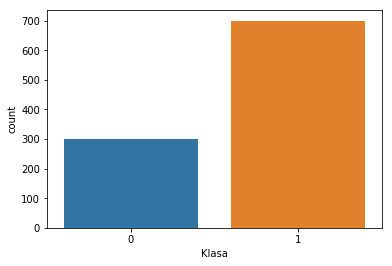

In [39]:
# Draw a Histogram
sns.countplot(data=baza, x="Klasa")

*Analiza uravnoteženosti klasa*

Nakon vizuelnog prikaza, koristimo numeričke funkcije kako bismo precizno izračunali odnos između klasa:

* `np.unique()`: Identifikuje sve jedinstvene oznake koje postoje u koloni `Klasa` (u ovom primeru nule i jedinice).
* `np.bincount()`: Prebrojava koliko se puta svaka od tih oznaka pojavljuje u skupu podataka.
*  Stepen neuravnoteženosti klasa (engl. Imbalance ratio): Odnos dobijenih vrednosti pokazuje kolika je relativna zastupljenost jedne klase u odnosu na drugu

In [40]:
print("Jedinstvene oznake: ", np.unique(baza["Klasa"]))
class_dist = np.bincount(baza["Klasa"])
print("Broj instanci u svakoj klasi:", class_dist)
print("Stepen neuravnoteženosti klasa:", class_dist/np.min(class_dist))

Jedinstvene oznake:  [0 1]
Broj instanci u svakoj klasi: [300 700]
Stepen neuravnoteženosti klasa: [1.         2.33333333]


Skup podataka za predviđanje kreditnog rizika pokazuje određeni stepen neuravnoteženosti. Izračunati odnos zastupljenosti klasa (1 : 2,33) pokazuje da je jedna klasa oko 2,3 puta brojnija od druge.

*Podela na trening i test skup*  

Pomoću funkcije `train_test_split`, ceo skup podataka se deli na test skup i trening skup. 

**Objašnjenje parametara i rezultata:**

* `train_test_split` – funkcija koja nasumično deli ulazne podatke na *trening* i *test* podskup, čime omogućava objektivnu procenu performansi modela.  
  - `X_train, X_test, y_train, y_test` – funkcija vraća četiri podskupa kako bi se razdvojio proces učenja od procesa evaluacije.
  - `X_train` i `y_train` čine trening skup na kojem model „uči“ obrasce iz podataka, gde je *X_train* skup nezavisnih promenljivih, a *y_train* skup zavisnih promenljivih (stvarne ciljne vrednosti ko je kupio proizvod) koji odgovaraju 'X_train' skupu. 
  - `X_test` i `y_test` koriste se za proveru koliko je model precizan na podacima koje ranije nije video, gde je *X_test* skup nezavisnih promenljivih na osnovu ovih podataka model vrši predviđanja, a *y_test* skup zavisnih promenljivih (stvarni ishodi za testni skup.).

* `test_size` – definiše koliki će procenat ukupnog skupa podataka biti izdvojen za testiranje modela, biramo `test_size = 0.3` kako bi se 30% podataka alociralo za testiranje performansi modela, dok se preostalih 70% koristi za proces treninga.

* `random_state` –Koristi se za postizanje reproduktivnosti rezultata. Postavljanje fiksne celobrojne vrednosti omogućava dobijanje identičnih ishoda pri svakom izvršavanju koda, čime se kontroliše slučajnost u procesu izgradnje modela.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = 149)

#prikazujemo veličinu trening i test skupa
print()
print("Trening skup: ", X_train.shape, y_train.shape)
print("Test skup: ", X_test.shape)


Trening skup:  (700, 20) (700,)
Test skup:  (300, 20)


*Normalizacija neprekidnih atributa pomoću MinMaxScaler-a*

Pošto se numeričke promenljive izražavaju u različitim jedinicama i opsezima, potrebno je izvršiti njihovu normalizaciju na interval od 0 do 1.

- `MinMaxScaler`: Metoda koja transformiše vrednosti tako da najmanja vrednost u koloni postaje 0, a najveća 1.  

- Postupak obrade:  
  - `fit`: Na osnovu trening skupa određuju se minimalne i maksimalne vrednosti.  
  - `transform`: Naučena transformacija se zatim primenjuje i na trening i na test skup podataka.  

- Značaj normalizacije:  
  Ovim postupkom se sprečava da atributi sa velikim numeričkim vrednostima (npr. iznos kredita izražen u hiljadama) imaju veći uticaj od atributa sa manjim vrednostima (npr. trajanje kredita u mesecima) tokom obučavanja modela.

Na kraju, proverom minimalnih i maksimalnih vrednosti potvrđuje se da su svi podaci uspešno preslikani u željeni opseg $[0, 1]$.


In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

kontrolneKolone = ['Trajanje_kredita', 'Iznos_kredita', 'Starost']

scaler.fit(X_train[kontrolneKolone])

X_train[kontrolneKolone] = scaler.transform(X_train[kontrolneKolone])
X_test[kontrolneKolone] = scaler.transform(X_test[kontrolneKolone])

print("Minimum %0.2f i Maximum %0.2f na trening setu" %(np.min(X_train[kontrolneKolone].values), np.max(X_train[kontrolneKolone].values)))

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:334: DataConversionWarning: Data with input dtype int64 were all converted to float64 by MinMaxScaler.
  return self.partial_fit(X, y)
C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  if __name__ == '__main__':
C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\indexing.py:543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self.obj[item] = s


Minimum 0.00 i Maximum 1.00 na trening setu


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  # Remove the CWD from sys.path while we load stuff.
C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\indexing.py:543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self.obj[item] = s


*Enkodiranje kategorijskih podataka (One-Hot Encoding)*

Naredni blok naredbi služi za pretvaranje kategorijskih kolona u numerički oblik pomoću `One-Hot Encoding` metode.

- OneHotEncoder: 
Najpre se kreira objekat enkodera:
`encoder = OneHotEncoder(handle_unknown='ignore')`

- `OneHotEncoder()` pretvara svaku kategorijsku vrednost u posebnu binarnu kolonu (0 ili 1).
- `handle_unknown='ignore'` ovaj parametar omogućava stabilan rad modela tako što sprečava grešku u slučaju da se u test skupu pojavi kategorija koja nije bila prisutna u trening skupu, takve vrednosti se jednostavno ignorišu.

Zatim se definiše lista kategorijskih kolona koje treba enkodirati:

`KontrolneKolone = ['Status_racuna', 'Kreditna_istorija', 'Svrha', 'Stednja', 'Licni_status', 'Drugi_duznici', 'Drugi_krediti', 'Stanovanje']`

Ova lista sadrži nazive svih kolona sa tekstualnim (kategorijskim) vrednostima.


- Proces transformacije:  
Sledeći korak je učenje enkodera na trening podacima:
- `fit()` identifikuje sve kategorije u svakoj koloni.
- `transform()` pretvara ih u numeričke vektore.
- Važno je da se ovo radi samo na trening skupu, kako bi se izbeglo curenje informacija iz test podataka.

- Rezultat:  
  Proverom dimenzija pomoću `.shape` može se uočiti povećanje broja kolona, jer svaka pojedinačna kategorija dobija sopstvenu binarnu reprezentaciju.

In [37]:
encoder = OneHotEncoder(handle_unknown = 'ignore')

KontrolneKolone = ['Status_racuna', 'Kreditna_istorija', 'Svrha', 'Stednja', 'Licni_status',
               'Drugi_duznici', 'Drugi_krediti', 'Stanovanje']

encoder.fit(X_train[KontrolneKolone])

X_train_encoded =  encoder.transform(X_train[KontrolneKolone])
X_test_encoded =  encoder.transform(X_test[KontrolneKolone])

X_train_encoded = pd.DataFrame(X_train_encoded.toarray())
X_test_encoded = pd.DataFrame(X_test_encoded.toarray())

X_train = X_train.drop(columns = KontrolneKolone)
X_test = X_test.drop(columns = KontrolneKolone)

X_train = np.concatenate((X_train.values, X_train_encoded.values), axis = 1)
X_test = np.concatenate((X_test.values, X_test_encoded.values), axis = 1)

print("Dimenzije podataka za obučavanje:", X_train.shape)
print("Dimenzije podataka za testiranje:", X_test.shape)

Dimenzije podataka za obučavanje: (700, 49)
Dimenzije podataka za testiranje: (300, 49)


S obzirom na to da su u skupu podataka i dalje prisutne originalne (stare) kolone, ukupan broj kolona je povećan, a kategorijske promenljive još uvek nisu u potpunosti uklonjene. To možemo jasno uočiti pozivanjem funkcije head(), koja prikazuje prvih pet redova tabele i omogućava proveru da li se kategorijske kolone i dalje nalaze u podacima.

In [38]:
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,0.0357143,0.034561,A73,1,2,A121,0.125,1,A172,2,...,0,0,0,1,0,1,0,0,1,0
1,0.357143,0.167618,A75,3,4,A122,0.607143,1,A173,1,...,0,1,0,0,0,0,1,0,1,0
2,0.107143,0.0632214,A73,2,2,A123,0.321429,1,A173,1,...,0,1,0,0,0,0,1,0,1,0
3,0.464286,0.233887,A73,4,4,A122,0.375,1,A174,1,...,0,1,0,0,0,0,1,0,1,0
4,0.25,0.110232,A74,4,1,A123,0.267857,2,A173,1,...,0,1,0,0,0,1,0,0,1,0


Pozivanjem `pd.DataFrame(X_train).info()` dobijamo da su sve kolone tipa object zato što `X_train` više nije DataFrame, već je postao NumPy niz (`ndarray`), zato što je za spajanje kolona korišćena funkcija `np.concatenate`. Ova funkcija vraća NumPy niz i time se gubi struktura DataFrame-a, uključujući nazive kolona i indekse.

Da bi se zadržao tabelarni oblik podataka i očuvale informacije o kolonama, umesto `np.concatenate` treba koristiti funkciju `pd.concat`, koja omogućava spajanje podataka uz očuvanje DataFrame strukture.

In [59]:
pd.DataFrame(X_train).info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 700 entries, 55 to 961
Data columns (total 49 columns):
Trajanje_kredita    700 non-null float64
Iznos_kredita       700 non-null float64
Radni_staz          700 non-null object
Stopa_rata          700 non-null int64
Vreme_stanovanja    700 non-null int64
Imovina             700 non-null object
Starost             700 non-null float64
Broj_kredita        700 non-null int64
Zaposlenost         700 non-null object
Broj_izdrzavanih    700 non-null int64
Telefon             700 non-null object
Strani_radnik       700 non-null object
0                   700 non-null float64
1                   700 non-null float64
2                   700 non-null float64
3                   700 non-null float64
4                   700 non-null float64
5                   700 non-null float64
6                   700 non-null float64
7                   700 non-null float64
8                   700 non-null float64
9                   700 non-null float64
10   

In [43]:
KontrolneKolone = ['Status_racuna', 'Kreditna_istorija', 'Svrha', 'Stednja', 'Licni_status',
               'Drugi_duznici', 'Drugi_krediti', 'Stanovanje', 'Radni_staz', 'Imovina', 'Zaposlenost','Telefon','Strani_radnik']

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore') 

encoder.fit(X_train[KontrolneKolone])

# Transformacija
X_train_encoded = encoder.transform(X_train[KontrolneKolone])
X_test_encoded = encoder.transform(X_test[KontrolneKolone])

# Pretvaranje u DataFrame
X_train_encoded = pd.DataFrame(
    X_train_encoded.toarray(),
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded.toarray(),
    index=X_test.index
)

# Izbacivanje kategorijskih kolona
X_train = X_train.drop(columns=KontrolneKolone)
X_test = X_test.drop(columns=KontrolneKolone)

# Spajanje pomoću concat (NE numpy!)
X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)		   

In [47]:
print(type(X_train)) # proveravamo da li je pandas DataFrame   
print(X_train.shape)
print(X_train.dtypes.unique()) 

<class 'pandas.core.frame.DataFrame'>
(700, 61)
[dtype('float64') dtype('int64')]


In [45]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 700 entries, 55 to 961
Data columns (total 61 columns):
Trajanje_kredita    700 non-null float64
Iznos_kredita       700 non-null float64
Stopa_rata          700 non-null int64
Vreme_stanovanja    700 non-null int64
Starost             700 non-null float64
Broj_kredita        700 non-null int64
Broj_izdrzavanih    700 non-null int64
0                   700 non-null float64
1                   700 non-null float64
2                   700 non-null float64
3                   700 non-null float64
4                   700 non-null float64
5                   700 non-null float64
6                   700 non-null float64
7                   700 non-null float64
8                   700 non-null float64
9                   700 non-null float64
10                  700 non-null float64
11                  700 non-null float64
12                  700 non-null float64
13                  700 non-null float64
14                  700 non-null float64


In [48]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators = 100, random_state = 1402)
random_forest.fit(X_train, y_train)

# accuracy: (tp + tn) / (p + n)
print("Training accuracy: ", random_forest.score(X_train, y_train))
print("Test accuracy: ", random_forest.score(X_test, y_test))

Training accuracy:  1.0
Test accuracy:  0.77


Preciznost za klasu klijente visokog rizika (lose klijente): 0.7058823529411765
Preciznost za klasu klijente niskog rizika (dobre klijente): 0.7831325301204819
Odziv za klasu klijente visokog rizika (lose klijente): 0.4
Odziv za klasu klijente niskog rizika (dobre klijente): 0.9285714285714286
F1 score za klasu klijente visokog rizika (lose klijente): 0.5106382978723405
F1 score za klasu klijente niskog rizika (dobre klijente): 0.8496732026143791


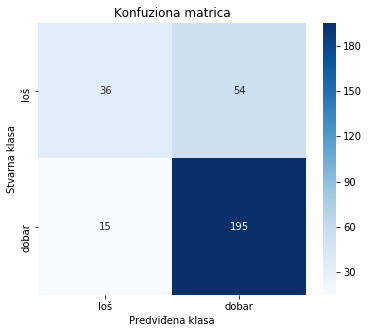

In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predikcija na test skupu
y_pred = random_forest.predict(X_test)

# -----------------------------
# Preciznost (Precision)
# -----------------------------
precision_los = precision_score(y_test, y_pred, pos_label=0)
precision_dobar = precision_score(y_test, y_pred, pos_label=1)
print("Preciznost za klasu klijente visokog rizika (lose klijente):", precision_los)
print("Preciznost za klasu klijente niskog rizika (dobre klijente):", precision_dobar)

# -----------------------------
# Odziv (Recall)
# -----------------------------
recall_los = recall_score(y_test, y_pred, pos_label=0)
recall_dobar = recall_score(y_test, y_pred, pos_label=1)
print("Odziv za klasu klijente visokog rizika (lose klijente):", recall_los)
print("Odziv za klasu klijente niskog rizika (dobre klijente):", recall_dobar)

# -----------------------------
# F1 Score
# -----------------------------
f1_los = f1_score(y_test, y_pred, pos_label=0)
f1_dobar = f1_score(y_test, y_pred, pos_label=1)
print("F1 score za klasu klijente visokog rizika (lose klijente):", f1_los)
print("F1 score za klasu klijente niskog rizika (dobre klijente):", f1_dobar)

# -----------------------------
# Konfuziona matrica
# -----------------------------
conf_mat = confusion_matrix(y_test, y_pred, labels=np.unique(y_train))

plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['loš', 'dobar'],
            yticklabels=['loš', 'dobar'])
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.title('Konfuziona matrica')
plt.show()


<br>

## Zadaci i problemi
<br>

:::{admonition} Zadatak 1 - Zadovoljstvo zaposlenih
:class: tip 

Jedna srednje velika kompanija suočava se sa povećanim odlaskom zaposlenih, što dovodi do rasta troškova zapošljavanja i obuke novih radnika. Menadžment želi da identifikuje ključne faktore koji utiču na odluku zaposlenih da napuste firmu, kako bi mogao da unapredi politiku zadržavanja kadrova.

Na raspolaganju je skup podataka koji sadrži informacije o zaposlenima, uključujući nivo plate, dužinu rada u kompaniji, zadovoljstvo poslom, prekovremeni rad, mogućnosti napredovanja i udaljenost od mesta stanovanja.

Skup podatak neophodan za ovaj zadatak se nalazi na sledećem linku [https://drive.google.com/file/d/1mq_D1WS_l-xjPcJFz-68ITV3k_ExGCvD/view?usp=sharing]

Za svakog zaposlenog poznato je da li je napustio kompaniju:
- `0` – zaposleni je ostao
- `1` – zaposleni je otišao

```{table} Opis promenljivih u skupu podataka:
:align: center
:header-rows: 1
| Promenljiva       | Tip promenljive | Opis                                                                                                        |
| ----------------- | --------------- | ----------------------------------------------------------------------------------------------------------- |
| salary            | numerička       | mesečna plata zaposlenog (u evrima); viši nivoi plate mogu smanjiti verovatnoću odlaska                     |
| years_in_company  | numerička       | broj godina provedenih u kompaniji; duži staž često ukazuje na veću lojalnost                               |
| job_satisfaction  | ordinalna       | nivo zadovoljstva poslom (skala 1–5); niže vrednosti povećavaju verovatnoću odlaska                         |
| overtime          | kategorijalna   | indikator prekovremenog rada (1 = da, 0 = ne); učestali prekovremeni rad može povećati rizik odlaska        |
| promotion_last_3y | kategorijalna   | indikator unapređenja u poslednje tri godine (1 = da, 0 = ne); izostanak napredovanja može povećati odlazak |
| distance_to_work  | numerička       | udaljenost od mesta stanovanja do posla (u km); veća udaljenost može povećati nezadovoljstvo                |
| left_company      | kategorijalna   | ciljna promenljiva (1 = zaposleni otišao, 0 = ostao)                                                        |
```

**Zahtevi:**
1. Podeli podatke na trening i test skup.
2. Izgradi Random Forest klasifikacioni model za predviđanje promenljive left_company.
3. Izvrši predikciju nad test skupom.
4. Oceni model korišćenjem confusion matrix i tačnosti.
5. Odredi značaj promenljivih u modelu.
6. Na osnovu rezultata odgovori:
     - koji faktori najviše utiču na odlazak zaposlenih?
     - da li plata ima presudan uticaj?
     - kako zadovoljstvo poslom utiče na odluku o odlasku?
7. Predloži konkretne mere koje menadžment može preduzeti kako bi smanjio odlazak zaposlenih.
:::

:::{admonition} Zadatak 2 - Predviđanje potrošnje
:class: tip 

Jedna finansijska institucija želi da predvidi nivo potrošnje domaćinstava na osnovu njihovih socio-ekonomskih karakteristika. Ta procena je važna za planiranje kreditnih proizvoda i procenu kreditne sposobnosti.

Na raspolaganju je skup podataka koji sadrži informacije o prihodima, veličini domaćinstva, obrazovanju, tipu naselja i štednji. Cilj je predvideti ukupnu mesečnu potrošnju domaćinstva.

Skup podatak neophodan za ovaj zadatak se nalazi na sledećem linku [https://drive.google.com/file/d/1uozylpxsziVW_2_41lVPcI7OtvTsZYhI/view?usp=sharing]

```{table} Opis promenljivih u skupu podataka:
:align: center
:header-rows: 1
| Promenljiva     | Tip promenljive | Opis                                          |
| --------------- | --------------- | --------------------------------------------- |
| income          | numerička       | mesečni prihod domaćinstva (u evrima)         |
| household_size  | numerička       | broj članova domaćinstva                      |
| education_level | kategorijalna   | nivo obrazovanja (0, 1, 2)                    |
| urban           | kategorijalna   | tip naselja (1 = urbano, 0 = ruralno)         |
| savings         | numerička       | ukupna štednja domaćinstva                    |
| consumption     | numerička       | ukupna mesečna potrošnja (ciljna promenljiva) |
```

**Zahtevi:**
1. Podeli podatke na trening i test skup.
2. Izgradi Random Forest regresioni model za predviđanje promenljive consumption.
3. Izvrši predikciju nad test skupom.
4. Evaluiraj model koristeći:
     - MAE
     - RMSE
5. Odredi značaj promenljivih u modelu.
6. Interpretiraj rezultate i odgovori:
    - koji faktor najviše utiče na potrošnju?
    - da li je odnos između prihoda i potrošnje linearan?
7. Predloži kako bi banka mogla koristiti ovaj model u praksi.

*Dodatni zahtevi:*

8. Izgradi i linearni regresioni model nad istim podacima.
9. Uporedi performanse modela (Random Forest vs linearna regresija).
10. Grafički prikaži odnos između stvarnih i predviđenih vrednosti za oba modela.
11. Diskutuj u kojim situacijama ansambl modeli daju bolje rezultate od linearnih modela.
12. (Napredno) Izgradi Gradient Boosting model i uporedi ga sa Random Forest modelom.

Napomena: Ansambl modeli zasnovani na stablima odlučivanja omogućavaju hvatanje nelinearnih odnosa između promenljivih, što ih čini posebno pogodnim za ekonomske podatke gde linearni modeli često nisu dovoljni.

## Literatura

```{bibliography}
:style: unsrt
:filter: docname in docnames